### Hyperstatic beam

Find the constraint reactions of the following fixed-fixed beam:

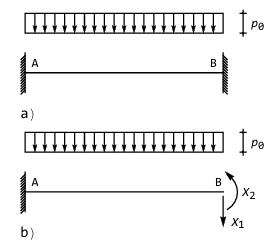

We can find $R_A, M_A, R_B, M_B$ using the superposition principle:

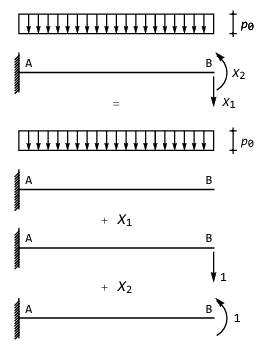

In [1]:
# Importing SymPy
import sympy as smp

In [2]:
# Defining global variables
z = smp.symbols("z", real = True, nonnegative = True)
u_y = smp.Function("u_y", real = True)(z)

# Defining constants
E, L, I, p0 = smp.symbols("E L I p_0", real = True, positive = True, constant = True)
R_B, M_B = smp.symbols("X_1 X_2", real = True, nonzero = True)

In [3]:
def solver(boundary, concentrated):

    if concentrated:
        eq = smp.Eq(smp.Derivative(u_y, z, 4), 0) # Equation to solve

        if boundary == 'cantilever beam force': # Concentrated force X_1 (our R_B) acts in z = L
            ics = {
                u_y.subs(z, 0): 0,
                smp.diff(u_y, z, 1).subs(z, 0): 0,

                smp.diff(u_y, z, 2).subs(z, L): 0,
                smp.diff(u_y, z, 3).subs(z, L): - R_B / (E * I)
                }
        
        if boundary == 'cantilever beam moment': # Concentrated bending moment X_2 (our M_B) acts in z = L
            ics = {
                u_y.subs(z, 0): 0,
                smp.diff(u_y, z, 1).subs(z, 0): 0,

                smp.diff(u_y, z, 2).subs(z, L): - M_B / (E * I),
                smp.diff(u_y, z, 3).subs(z, L): 0
                }
    
    else:
        eq = smp.Eq(smp.Derivative(u_y, z, 4), p0 / (E * I)) # Equation to solve
            
        if boundary == 'cantilever beam': # Classical constant load problem
            ics = {
                u_y.subs(z, 0): 0,
                smp.diff(u_y, z, 1).subs(z, 0): 0,

                smp.diff(u_y, z, 2).subs(z, L): 0,
                smp.diff(u_y, z, 3).subs(z, L): 0
                }
    
    sol = smp.dsolve(eq, u_y, ics = ics).rhs.factor() # Solving the equations with the choosen boundaries
    theta = - smp.diff(sol, z, 1).factor() # Computing the angle

    sol = (sol, theta)

    return sol

In [4]:
# Solution for a cantilever beam with constant load applied
sol_p0 = solver(boundary = 'cantilever beam',
                concentrated = False)
sol_p0

(p_0*z**2*(6*L**2 - 4*L*z + z**2)/(24*E*I),
 -p_0*z*(3*L**2 - 3*L*z + z**2)/(6*E*I))

In [5]:
# Solution for a cantilever beam with concentrated force applied
sol_F = solver(boundary = 'cantilever beam force',
               concentrated = True)
sol_F

(-X_1*z**2*(-3*L + z)/(6*E*I), X_1*z*(-2*L + z)/(2*E*I))

In [6]:
# Solution for a cantilever beam with concentrated bending moment applied
sol_M = solver(boundary = 'cantilever beam moment',
               concentrated = True)
sol_M

(-X_2*z**2/(2*E*I), X_2*z/(E*I))

In [7]:
# Total displacement and angle
sol = sol_p0[0] + sol_F[0] + sol_M[0]
angle = sol_p0[1] + sol_F[1] + sol_M[1]
sol, angle

(-X_1*z**2*(-3*L + z)/(6*E*I) - X_2*z**2/(2*E*I) + p_0*z**2*(6*L**2 - 4*L*z + z**2)/(24*E*I),
 X_1*z*(-2*L + z)/(2*E*I) + X_2*z/(E*I) - p_0*z*(3*L**2 - 3*L*z + z**2)/(6*E*I))

By imposing:

\begin{cases}
    u_y^{tot}(z = L) = 0 \\
    \theta^{tot}(z = L) = 0
\end{cases}

We obtain a linear system in $X_1$ and $X_2$. Solve it to get $R_B$ and $M_B$

In [8]:
# System
eq1 = smp.Eq(sol.subs(z, L), 0)
eq2 = smp.Eq(angle.subs(z, L), 0)
eq1, eq2

(Eq(L**4*p_0/(8*E*I) + L**3*X_1/(3*E*I) - L**2*X_2/(2*E*I), 0),
 Eq(-L**3*p_0/(6*E*I) - L**2*X_1/(2*E*I) + L*X_2/(E*I), 0))

In [9]:
# Matrix form
A, b = smp.linear_eq_to_matrix([eq1, eq2], [R_B, M_B])
A, b

(Matrix([
 [ L**3/(3*E*I), -L**2/(2*E*I)],
 [-L**2/(2*E*I),       L/(E*I)]]),
 Matrix([
 [-L**4*p_0/(8*E*I)],
 [ L**3*p_0/(6*E*I)]]))

In [10]:
# Solution
R_B, M_B = A.inv() * b
R_B, M_B

(-L*p_0/2, -L**2*p_0/12)

By applying the mechanics equilibrium condition:

$$
    R_A + R_B + p_0 L = 0 \\
    M_A + M_B + \frac{p_0 L ^ 2}{2} = 0
$$

We get $R_A$ and $M_A$

In [11]:
R_A = - p0 * L - R_B
M_A = - p0 * L ** 2 / 2 - M_B
R_A, M_A

(-L*p_0/2, -5*L**2*p_0/12)